In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import encosid

In [2]:
MOTOR_IF = "can0"
MOTOR_ID = 3
BRAKE_ID = 4

SIGNAL_DT_MS = 1
MOTOR_KT = 4.2

## Измерение отклика

Управление по USB-CAN

In [3]:
# Устрание разрывов позиции (перескок на 2pi)
def stitch(Y, gap=2*np.pi, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy
    if np.abs(dy) >= gap - tol:
      Y[i + 1:] -= shift
  return Y

# Пример процедуры измерения
def measure_responce(ctrl, dt):
  gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)

  gen.set_mode(gen.mode.torque, 0)
  # gen.set_mode(gen.mode.position, kp) # kp < 500
  # gen.set_mode(gen.mode.velocity, kd) # kd < 5
  resp = gen.play_signal(ctrl, dt)
  pos, vel, cur = map(np.array, resp[0:3])
  err = resp[3]

  pos = stitch(pos - pos[0])
  vel = savgol_filter(vel, 101, 3)
  trq = MOTOR_KT * savgol_filter(cur, 101, 3)
  
  return pos, vel, trq, err

/tmp/ipykernel_19122/3328545190.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


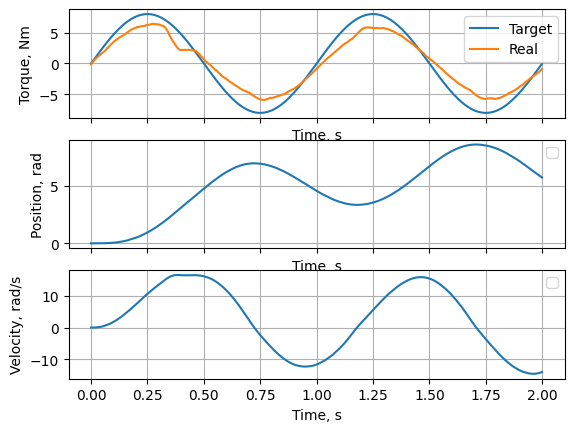

In [ ]:
T = np.arange(0, 2, 1e-3 * SIGNAL_DT_MS)
ctrl = 8 * np.sin(2 * np.pi * T)
pos, vel, trq, err = measure_responce(ctrl, SIGNAL_DT_MS)

fig, ax = plt.subplots(3, 1, sharex = True)

ax[0].set_ylabel("Torque, Nm")
ax[0].plot(T, ctrl, label="Target")
ax[0].plot(T, trq, label="Real")

ax[1].set_ylabel("Position, rad")
ax[1].plot(T, pos)

ax[2].set_ylabel("Velocity, rad/s")
ax[2].plot(T, vel)

for axis in ax:
    axis.set_xlabel("Time, s")
    axis.grid()
    axis.legend()

plt.show()

## Position scale check

This cell sends zero torque and records the decoded position (`qpos`) from the motor response. Use it to check whether the C++ position scale (`posMax`) matches the real encoder/firmware scale.

Keep the motor mechanically safe while running this: zero torque means the rotor is not actively held.

In [ ]:
QPOS_DT_MS = 5
QPOS_DURATION_S = 5

zero_torque = np.zeros(int(QPOS_DURATION_S * 1000 / QPOS_DT_MS), dtype=float)

qpos_gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)
qpos_gen.set_mode(qpos_gen.mode.torque, 0)

qpos, qvel, qcur = map(np.array, qpos_gen.play_signal(zero_torque, QPOS_DT_MS)[0:3])
t_qpos = np.arange(len(qpos)) * QPOS_DT_MS * 1e-3

print(f"samples: {len(qpos)}")
print(f"qpos start: {qpos[0]:.6f} rad")
print(f"qpos end:   {qpos[-1]:.6f} rad")
print(f"qpos min:   {qpos.min():.6f} rad")
print(f"qpos max:   {qpos.max():.6f} rad")
print(f"qpos span:  {qpos.max() - qpos.min():.6f} rad")

plt.figure(figsize=(10, 4))
plt.plot(t_qpos, qpos, label="decoded qpos")
plt.xlabel("Time, s")
plt.ylabel("Position, rad")
plt.grid()
plt.legend()
plt.show()

# Miscelanneous

In [28]:
import encosid
encosid.set_zero("can0")

Found id #6


In [20]:
import encosid
import numpy as np
import time

encosid.get_id("can0")
MOTOR_ID = encosid.get_id("can0")

signal = np.zeros((1000,))
gen = encosid.SignalGenerator("can0", MOTOR_ID)
time.sleep(3)
gen.play_pd_signal(signal, signal, 3, 1, 1)
gen.play_pd_signal(signal, signal, 10, 1, 1)
gen.play_pd_signal(signal, signal, 100, 1, 1)

Found id #6
Found id #6


[[0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,
  0.00457763671875,


# Error return check

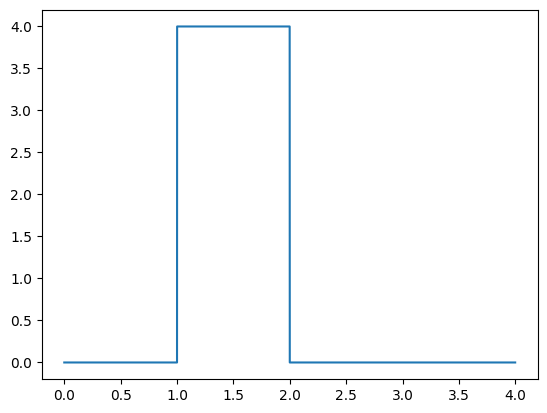

In [4]:
TIME_S = 4
FREQUENCY_HZ = .3
AMPLITUDE_NM = 4

T = np.arange(0, TIME_S, SIGNAL_DT_MS * 1e-3)
X = AMPLITUDE_NM * ((T > TIME_S / 4)*(T < TIME_S / 2))

plt.plot(T, X)

In [7]:
encosid.get_id("can0")
MOTOR_ID = encosid.get_id("can0")

gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)
gen.set_mode(gen.mode.torque, 0)

qpos, qvel, qtrq, err = measure_responce(X, SIGNAL_DT_MS)


Found id #4
Found id #4


{'NoError'}


/tmp/ipykernel_9222/3588391947.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


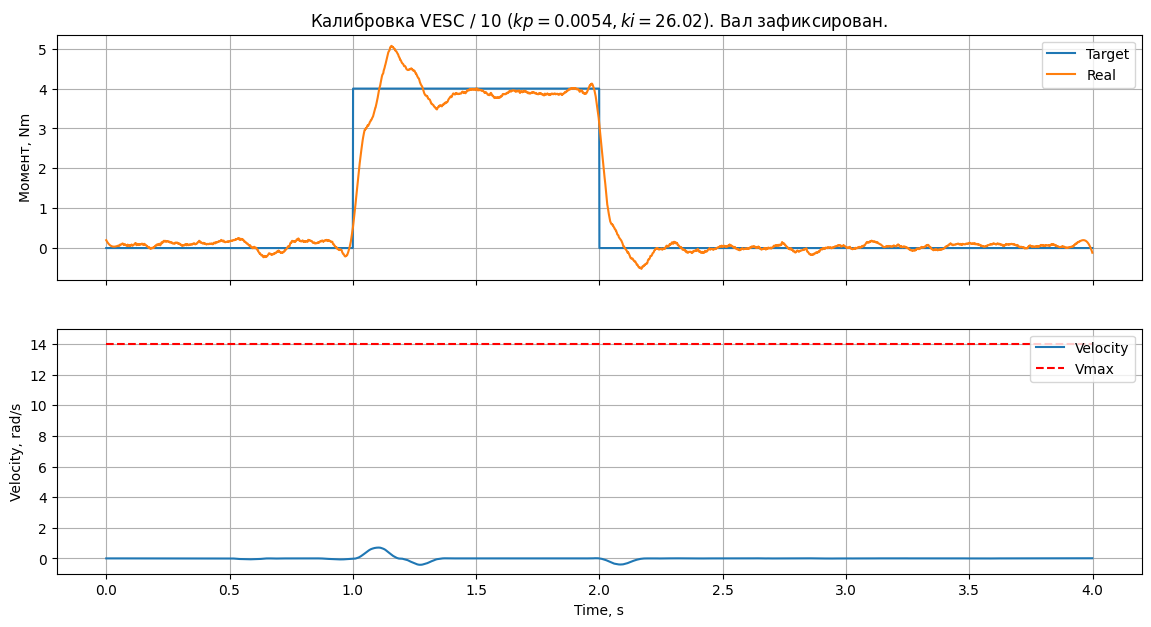

In [8]:
print(set(err))

LABEL = "Калибровка VESC / 10 ($kp = 0.0054, ki = 26.02$). Вал зафиксирован."

fig, ax = plt.subplots(2, 1, sharex=True)
fig.set_size_inches((14, 7))

ax[0].plot(T, X, label="Target")
ax[0].plot(T, qtrq, label="Real")
ax[0].set_title(LABEL)
ax[0].set_ylabel("Момент, Nm")
ax[0].legend()
ax[0].grid()

ax[1].plot(T, qvel, label="Velocity")
ax[1].hlines(14, 0, TIME_S, linestyle="--", color="r", label="Vmax")
ax[1].set_ylim(-1, 15)
ax[1].set_ylabel("Velocity, rad/s")
ax[1].set_xlabel("Time, s")
ax[1].legend()
ax[1].grid()

fig.show()
